In [4]:
# Cell 1 — TF 2.19 is the first version compatible with ml_dtypes 0.5+
!pip install -q --force-reinstall \
    "numpy==1.26.4" \
    "ml_dtypes==0.5.1" \
    "tensorflow==2.19.0" \
    "tf-keras==2.19.0" \
    "transformers==4.46.3" \
    "huggingface_hub==0.26.5"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.8/447.8 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [1]:
# Cell 2 — verify
import numpy, ml_dtypes, tensorflow
print("numpy:     ", numpy.__version__)       # 1.26.4
print("ml_dtypes: ", ml_dtypes.__version__)   # 0.5.1
print("tensorflow:", tensorflow.__version__)  # 2.19.0

numpy:      1.26.4
ml_dtypes:  0.5.1
tensorflow: 2.19.0


In [2]:
import re
import tensorflow as tf
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/clean_tweets.csv")
df

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,retweet_count,text,tweet_created,tweet_length
0,neutral,1.0000,No reason,0.0000,Virgin America,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:00,35
1,positive,0.3486,No reason,0.0000,Virgin America,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:00,72
2,neutral,0.6837,No reason,0.0000,Virgin America,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:00,71
3,negative,1.0000,Bad Flight,0.7033,Virgin America,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:00,126
4,negative,1.0000,Can't Tell,1.0000,Virgin America,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:00,55
...,...,...,...,...,...,...,...,...,...
14595,positive,0.3487,No reason,0.0000,American,0,@AmericanAir thank you we got on a different f...,2015-02-22 12:01:00,63
14596,negative,1.0000,Customer Service Issue,1.0000,American,0,@AmericanAir leaving over 20 minutes Late Flig...,2015-02-22 11:59:00,150
14597,neutral,1.0000,No reason,0.0000,American,0,@AmericanAir Please bring American Airlines to...,2015-02-22 11:59:00,60
14598,negative,1.0000,Customer Service Issue,0.6659,American,0,"@AmericanAir you have my money, you change my ...",2015-02-22 11:59:00,135


In [5]:
# Keep only the columns needed for Week 2
df = df[['text', 'airline_sentiment']].copy()

In [6]:
df

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative
...,...,...
14595,@AmericanAir thank you we got on a different f...,positive
14596,@AmericanAir leaving over 20 minutes Late Flig...,negative
14597,@AmericanAir Please bring American Airlines to...,neutral
14598,"@AmericanAir you have my money, you change my ...",negative


In [7]:
df['airline_sentiment'].unique()

array(['neutral', 'positive', 'negative'], dtype=object)

In [8]:
# Simple stop words list
stop_words = {
    "a", "an", "and", "are", "as", "at", "be", "but", "by", "for", "from",
    "has", "have", "he", "her", "his", "i", "in", "is", "it", "its", "me",
    "my", "of", "on", "or", "our", "so", "that", "the", "their", "them",
    "there", "they", "this", "to", "was", "were", "what", "when", "where",
    "which", "who", "will", "with", "you", "your", "about", "can", "could",
    "would", "should", "dont", "didnt", "im", "ive", "we", "had", "did"
}

In [9]:
# Simple slang normalization
slang_map = {
    "luv": "love",
    "plz": "please",
    "pls": "please",
    "wth": "what the hell",
    "omg": "oh my god",
    "cant": "cannot",
    "can't": "cannot",
    "wanna": "want to",
    "gonna": "going to",
    "b4": "before",
    "u": "you",
    "r": "are",
    "n't": " not"
}

In [10]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # remove URLs
    text = re.sub(r"@\w+", " ", text)               # remove mentions
    text = re.sub(r"#[\w-]+", " ", text)            # remove hashtags
    text = re.sub(r"[^a-z0-9\s]", " ", text)        # remove emojis/punctuation
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()
    words = [slang_map.get(w, w) for w in words]
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

In [11]:
# Apply preprocessing
df["clean_text"] = df["text"].apply(preprocess_text)

In [12]:
df

,text,airline_sentiment,clean_text
0,@VirginAmerica What @dhepburn said.,neutral,said
1,@VirginAmerica plus you've added commercials t...,positive,plus ve added commercials experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,neutral,didn t today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,negative,s really aggressive blast obnoxious entertainm...
4,@VirginAmerica and it's a really big bad thing...,negative,s really big bad thing
...,...,...,...
14595,@AmericanAir thank you we got on a different f...,positive,thank got different flight chicago
14596,@AmericanAir leaving over 20 minutes Late Flig...,negative,leaving over 20 minutes late flight no warning...
14597,@AmericanAir Please bring American Airlines to...,neutral,please bring american airlines
14598,"@AmericanAir you have my money, you change my ...",negative,money change flight don t answer phones any ot...


In [13]:
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [ ]:
# ENCODE LABELS
# LabelEncoder gives us:  negative→0, neutral→1, positive→2  (alphabetical)
# We also store num_labels for the model head.

le = LabelEncoder()
df["label"] = le.fit_transform(df["airline_sentiment"])
# le.classes_ → ['negative' 'neutral' 'positive']
num_labels = len(le.classes_)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [15]:
df

,text,airline_sentiment,clean_text,label
0,@VirginAmerica What @dhepburn said.,neutral,said,1
1,@VirginAmerica plus you've added commercials t...,positive,plus ve added commercials experience tacky,2
2,@VirginAmerica I didn't today... Must mean I n...,neutral,didn t today must mean need take another trip,1
3,@VirginAmerica it's really aggressive to blast...,negative,s really aggressive blast obnoxious entertainm...,0
4,@VirginAmerica and it's a really big bad thing...,negative,s really big bad thing,0
...,...,...,...,...
14595,@AmericanAir thank you we got on a different f...,positive,thank got different flight chicago,2
14596,@AmericanAir leaving over 20 minutes Late Flig...,negative,leaving over 20 minutes late flight no warning...,0
14597,@AmericanAir Please bring American Airlines to...,neutral,please bring american airlines,1
14598,"@AmericanAir you have my money, you change my ...",negative,money change flight don t answer phones any ot...,0


In [ ]:
#TRAIN / VALIDATION / TEST SPLIT
#train  – model learns from this
#val    – we monitor loss here each epoch to catch overfitting early
#test   – final, untouched evaluation (never used during training)
#stratify= keeps class ratios equal across all three splits.

X = df["clean_text"].values
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 11680 | Val: 1460 | Test: 1460


In [ ]:
# TOKENISATION 
# DistilBERT does NOT read plain text.  It reads token IDs — integers
# that map to its 30,522-word vocabulary.  The tokenizer also builds an
# attention_mask (1 = real token, 0 = padding) so the model ignores padding.
#
# MAX_LEN = 128  – tweets are short; 128 covers >99 % of them and saves RAM.
# truncation=True  – longer texts are cut to MAX_LEN.
# padding='max_length' – shorter texts are zero-padded to MAX_LEN so every
#                        batch tensor has the same shape.

MAX_LEN    = 128
MODEL_NAME = "distilbert-base-uncased"  # uncased = lowercased input, matches our cleaning

tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(
        list(texts),
        max_length=MAX_LEN,
        truncation=True,
        padding="max_length",
        return_tensors="tf"   # return TensorFlow tensors directly
    )

train_enc = tokenize(X_train)
val_enc   = tokenize(X_val)
test_enc  = tokenize(X_test)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
BATCH_SIZE = 32   # 16–32 is safe for most GPUs; lower if you get OOM errors

def make_dataset(encodings, labels, shuffle=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (
            {
                "input_ids":      encodings["input_ids"],
                "attention_mask": encodings["attention_mask"]
            },
            labels
        )
    )
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=SEED)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_enc, y_train, shuffle=True)
val_ds   = make_dataset(val_enc,   y_val)
test_ds  = make_dataset(test_enc,  y_test)

In [46]:
from transformers import DistilBertConfig

config = DistilBertConfig.from_pretrained(MODEL_NAME)
config.num_labels = num_labels # Set the number of labels in the config
config.seq_classif_dropout = 0.6 # Set dropout for the classification head
config.dropout = 0.2 # Increase general dropout in DistilBERT layers
config.attention_dropout = 0.2 # Increase attention dropout in DistilBERT layers

model = TFDistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    config=config
)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.bias', 'vocab_projector.bias', 'vocab_layer_norm.weight', 'vocab_layer_norm.bias', 'vocab_transform.weight']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

In [ ]:
# COMPILE
# Optimizer : Adam with a tiny learning rate (2e-5 is the standard for BERT
#             fine-tuning; too high destroys pretrained weights).
# Loss      : SparseCategoricalCrossentropy(from_logits=True) because:
#               • "Sparse" = labels are integers (not one-hot vectors)
#               • from_logits=True = the model outputs raw scores, not softmax
#                 probabilities; TF applies softmax internally (more numerically
#                 stable).
# Metrics   : accuracy is intuitive but class-imbalanced; we'll compute
#             precision/recall/F1 properly after training via sklearn.

LEARNING_RATE = 5e-6

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss      = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
model.summary()

Model: "tf_distil_bert_for_sequence_classification_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 distilbert (TFDistilBertMa  multiple                  66362880  
 inLayer)                                                        
                                                                 
 pre_classifier (Dense)      multiple                  590592    
                                                                 
 classifier (Dense)          multiple                  2307      
                                                                 
 dropout_119 (Dropout)       multiple                  0 (unused)
                                                                 
Total params: 66955779 (255.42 MB)
Trainable params: 66955779 (255.42 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
# CALLBACKS
# EarlyStopping  – stops training when val_loss stops improving for 2 epochs.
#                  Prevents overfitting and saves training time.
# ModelCheckpoint– saves the best weights (lowest val_loss) automatically so
#                  you don't have to keep training until the last epoch.

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=2, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_distilbert_model",   # saves as SavedModel folder
        monitor="val_loss",
        save_best_only=True
    )
]

In [ ]:
# TRAIN
# EPOCHS = 10  – Give the model more room to train, relying on EarlyStopping
#                  to prevent overfitting.

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
365/365 [==============================] - ETA: 0s - loss: 0.7890 - accuracy: 0.6415

365/365 [==============================] - 217s 520ms/step - loss: 0.7890 - accuracy: 0.6415 - val_loss: 0.6576 - val_accuracy: 0.7384
Epoch 2/10
365/365 [==============================] - ETA: 0s - loss: 0.5833 - accuracy: 0.7768

365/365 [==============================] - 199s 545ms/step - loss: 0.5833 - accuracy: 0.7768 - val_loss: 0.5301 - val_accuracy: 0.7842
Epoch 3/10
365/365 [==============================] - ETA: 0s - loss: 0.4954 - accuracy: 0.8084

365/365 [==============================] - 195s 533ms/step - loss: 0.4954 - accuracy: 0.8084 - val_loss: 0.4998 - val_accuracy: 0.8007
Epoch 4/10
365/365 [==============================] - ETA: 0s - loss: 0.4492 - accuracy: 0.8280

365/365 [==============================] - 178s 487ms/step - loss: 0.4492 - accuracy: 0.8280 - val_loss: 0.4954 - val_accuracy: 0.8055
Epoch 5/10
365/365 [==============================] - ETA: 0s - loss: 0.4175 - accuracy: 0.8443

365/365 [==============================] - 189s 518ms/step - loss: 0.4175 - accuracy: 0.8443 - val_loss: 0.4913 - val_accuracy: 0.8082
Epoch 6/10
365/365 [==============================] - 151s 414ms/step - loss: 0.3911 - accuracy: 0.8511 - val_loss: 0.4968 - val_accuracy: 0.8082
Epoch 7/10
365/365 [==============================] - 151s 413ms/step - loss: 0.3655 - accuracy: 0.8646 - val_loss: 0.5030 - val_accuracy: 0.8116


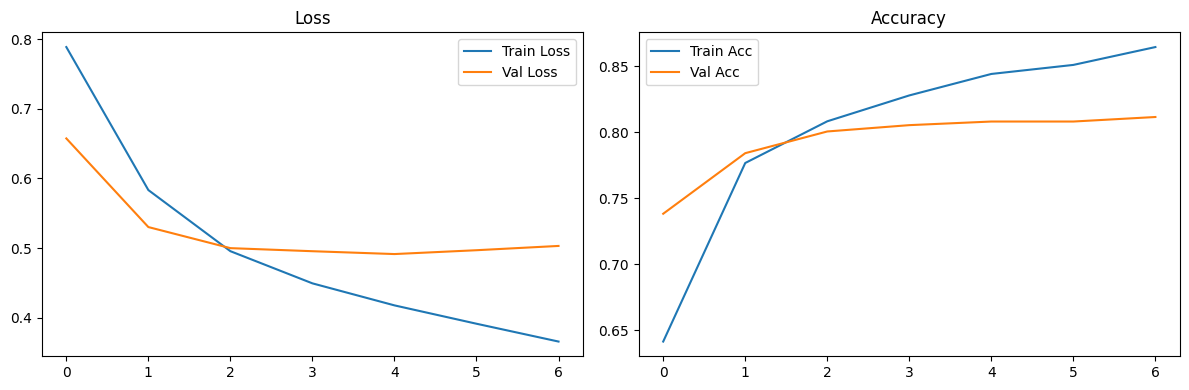

In [ ]:
#PLOT TRAINING CURVES
#Visual check for overfitting.
#   • Healthy: train_loss and val_loss both fall together.
#   • Overfit : train_loss keeps falling but val_loss rises.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"],     label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"],     label="Train Acc")
axes[1].plot(history.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].legend()
    
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

46/46 [==============================] - 8s 138ms/step

── Classification Report ──
              precision    recall  f1-score   support

    negative       0.90      0.87      0.88       915
     neutral       0.66      0.68      0.67       309
    positive       0.72      0.78      0.75       236

    accuracy                           0.82      1460
   macro avg       0.76      0.78      0.77      1460
weighted avg       0.82      0.82      0.82      1460



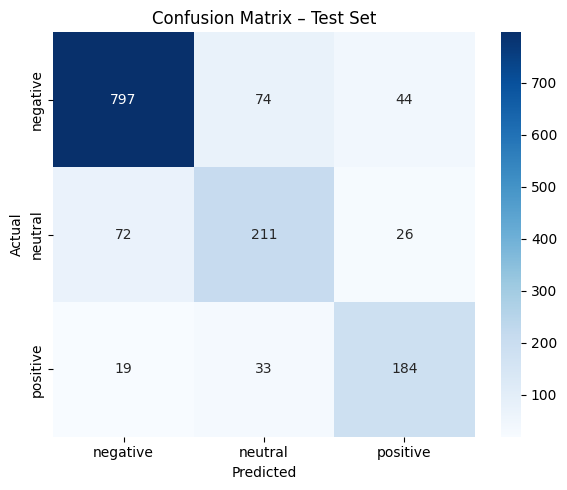

In [ ]:
# EVALUATE ON TEST SET
# get raw logits from the model
raw_preds = model.predict(test_ds)
logits    = raw_preds.logits                      # shape (N, 3)
y_pred    = np.argmax(logits, axis=1)             # predicted class index

print("\n── Classification Report ──")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Test Set")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


In [ ]:
# INFERENCE ON NEW TEXT

def predict_sentiment(texts: list[str]) -> list[str]:
    cleaned  = [preprocess_text(t) for t in texts]
    enc      = tokenize(cleaned)
    dataset  = tf.data.Dataset.from_tensor_slices({
        "input_ids":      enc["input_ids"],
        "attention_mask": enc["attention_mask"]
    }).batch(BATCH_SIZE)
    logits   = model.predict(dataset).logits
    indices  = np.argmax(logits, axis=1)
    return le.inverse_transform(indices)   # back to string labels

samples = [
    "The flight was delayed by 3 hours and no one explained why.",
    "Amazing crew, super smooth landing, loved it!",
    "Seat was okay I guess, nothing special.",
    "How are you?",
    "This man is very prespecious",
    "He is looking"
]
for text, pred in zip(samples, predict_sentiment(samples)):
    print(f"  [{pred:>8}]  {text}")

1/1 [==============================] - 0s 64ms/step
  [negative]  The flight was delayed by 3 hours and no one explained why.
  [positive]  Amazing crew, super smooth landing, loved it!
  [negative]  Seat was okay I guess, nothing special.
  [ neutral]  How are you?
  [positive]  This man is very prespecious
  [ neutral]  He is looking
